In [1]:
import tensorflow as tf
from keras.models import Sequential
from keras import layers
import keras
from keras.layers import Dense, Activation, Flatten, Conv2D, MaxPooling2D
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os
import cv2

2025-02-05 13:59:48.233644: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
mnist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = keras.utils.normalize(x_train,axis=1)
x_test = keras.utils.normalize(x_test,axis=1)

In [3]:
print("Train Data Shape",x_train.shape)
print("Test Data Shape",x_test.shape)

Train Data Shape (60000, 28, 28)
Test Data Shape (10000, 28, 28)


In [4]:
x_train = x_train.reshape((x_train.shape[0],x_train.shape[1],x_train.shape[2],1))
x_test = x_test.reshape((x_test.shape[0],x_test.shape[1],x_test.shape[2],1))


In [5]:
x_train[0].shape

(28, 28, 1)

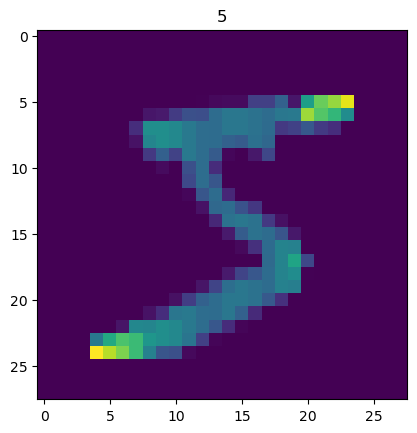

In [6]:
plt.imshow(x_train[0])
plt.title(y_train[0])
plt.show()

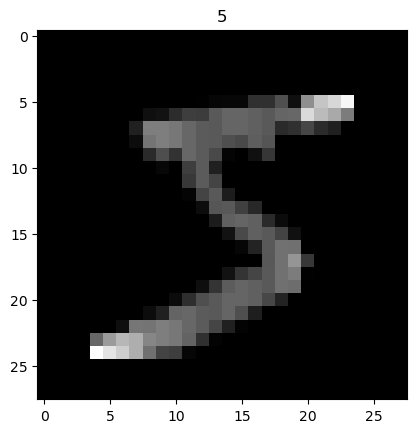

In [7]:
plt.imshow(x_train[0],cmap='gray')
plt.title(y_train[0])
plt.show()

In [8]:
model = Sequential()
model.add(layers.Conv2D(filters=16,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)))
model.add(layers.Conv2D(filters=16,kernel_size=(3,3),activation='relu'))
model.add(layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu'))
model.add(layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(units=84,activation='relu'))
model.add(layers.Dense(units=24,activation='relu'))
model.add(layers.Dense(units=10,activation='softmax'))
model.compile(loss=keras.losses.sparse_categorical_crossentropy, optimizer=keras.optimizers.Adam(),metrics=['accuracy'])
model.summary()

/home/ansh-yadav/.miniconda3/envs/jupyter-lab/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 22, 22, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 84)             │     1,075,284 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         2,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,093,942 (4.17 MB)

 Trainable params: 1,093,942 (4.17 MB)

 Non-trainable params: 0 (0.00 B)

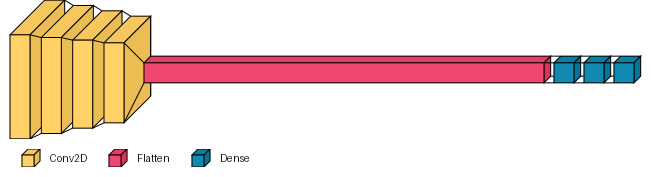

In [12]:
import visualkeras
from PIL import ImageFont
#font = ImageFont.truetype("arial.ttf",25)
visualkeras.layered_view(model,legend=True)

In [14]:
hist = model.fit(x_train,y_train,epochs=5,batch_size=20,validation_split=0.2)

Epoch 1/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 50s 21ms/step - accuracy: 0.9957 - loss: 0.0129 - val_accuracy: 0.9841 - val_loss: 0.0727
Epoch 2/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 45s 19ms/step - accuracy: 0.9970 - loss: 0.0114 - val_accuracy: 0.9858 - val_loss: 0.0707
Epoch 3/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 45s 19ms/step - accuracy: 0.9969 - loss: 0.0093 - val_accuracy: 0.9877 - val_loss: 0.0631
Epoch 4/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 47s 19ms/step - accuracy: 0.9983 - loss: 0.0067 - val_accuracy: 0.9839 - val_loss: 0.0783
Epoch 5/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 50s 21ms/step - accuracy: 0.9976 - loss: 0.0071 - val_accuracy: 0.9873 - val_loss: 0.0896


In [15]:
test_loss, test_acc = model.evaluate(x_test,y_test)
print("Test Loss", test_loss)
print("Test Accuracy", test_acc)
prediction = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9868 - loss: 0.0832
Test Loss 0.07034304738044739
Test Accuracy 0.9886000156402588
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step 


In [18]:
# Visulaizing the imapcat of each layer on an input image
test_model = Sequential()
test_model.add(layers.Conv2D(3,(3,3),input_shape=x_train[0].shape,activation='relu'))

In [20]:
def visualize_h(test_model,h):
    h_batch = np.expand_dims(h,axis=0)
    conv_h = test_model.predict(h_batch)
    conv_h = np.squeeze(conv_h,axis=0)
    plt.imshow(conv_h)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


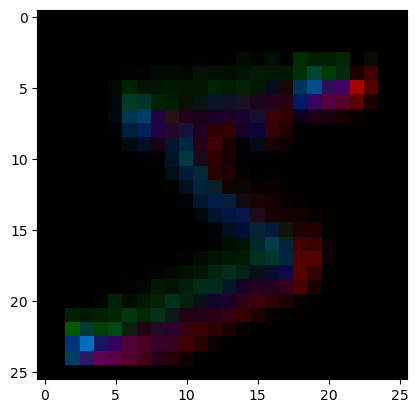

In [22]:
visualize_h(test_model,x_train[0])